# 01 — Data Loading & Exploratory Data Analysis

**Dataset:** CiaoDVD (`ratings.txt`, `trust.txt`)  
**Goal:** Load the data, report basic statistics, check data quality, and visualize key distributions.

---

## 1. Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Paths
RAW_DATA_DIR = '../data/raw/'
PROCESSED_DATA_DIR = '../data/processed/'
FIGURES_DIR = '../results/figures/'

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2. Load Data

In [10]:
# Load ratings
ratings = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'ratings.txt'),
    sep='\s+',
    header=None,
    names=['userId', 'movieId', 'rating']
)
print(ratings.shape)
print(ratings.head())

(35497, 3)
   userId  movieId  rating
0       1        1     2.0
1       1        2     4.0
2       1        3     3.5
3       1        4     3.0
4       1        5     4.0


In [11]:
# Load trust network
trust = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'trust.txt'),
    sep='\s+',
    header=None,
    names=['trustorId', 'trusteeId', 'trustRating']
)

print(trust.shape)
print(trust.head())

(1853, 3)
   trustorId  trusteeId  trustRating
0          2        966            1
1          2        104            1
2          5       1509            1
3          6       1192            1
4          7       1510            1


---
## 3. Basic Statistics

In [26]:
n_users   = ratings['userId'].nunique()
n_movies  = ratings['movieId'].nunique()
n_ratings = len(ratings)

# Sparsity: proportion of the user-item matrix that is empty
possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print('=' * 40)
print(f'  Users            : {n_users:,}')
print(f'  Movies           : {n_movies:,}')
print(f'  Ratings          : {n_ratings:,}')
print(f'  Possible entries : {possible_ratings:,}')
print(f'  Sparsity         : {sparsity:.4%}')
print('=' * 40)

  Users            : 1,508
  Movies           : 2,071
  Ratings          : 35,497
  Possible entries : 3,123,068
  Sparsity         : 98.8634%


In [13]:
print('Rating column stats:')
print(ratings['rating'].describe())
print(f'\nUnique rating values: {sorted(ratings["rating"].unique())}')

Rating column stats:
count    35497.000000
mean         3.002803
std          0.918692
min          0.500000
25%          2.500000
50%          3.000000
75%          4.000000
max          4.000000
Name: rating, dtype: float64

Unique rating values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0)]


---
## 4. Data Quality Check

In [14]:
print('Missing values per column:')
print(ratings.isnull().sum())

Missing values per column:
userId     0
movieId    0
rating     0
dtype: int64


In [15]:
# Check for duplicate (userId, movieId) pairs — a user rating the same movie twice
n_dupes = ratings.duplicated(subset=['userId', 'movieId']).sum()
print(f'Duplicate (userId, movieId) pairs: {n_dupes}')

Duplicate (userId, movieId) pairs: 3


In [16]:
# Check for out-of-range ratings (should be 1-5)
invalid_ratings = ratings[~ratings['rating'].between(1, 5)]
print(f'Ratings outside 1-5 range: {len(invalid_ratings)}')

if len(invalid_ratings) > 0:
    print(invalid_ratings['rating'].value_counts())

Ratings outside 1-5 range: 1060
rating
0.5    1060
Name: count, dtype: int64


In [17]:
# Drop duplicates — keep the first occurrence
ratings_clean = ratings.drop_duplicates(subset=['userId', 'movieId']).copy()

# Drop any rows with missing ratings
ratings_clean = ratings_clean.dropna(subset=['rating'])

# Keep only valid ratings
ratings_clean = ratings_clean[ratings_clean['rating'].between(1, 5)]

# Keep only the columns needed for modeling
ratings_clean = ratings_clean[['userId', 'movieId', 'rating']].reset_index(drop=True)

print(f'Rows before cleaning : {n_ratings:,}')
print(f'Rows after cleaning  : {len(ratings_clean):,}')
print(f'Rows removed         : {n_ratings - len(ratings_clean):,}')

Rows before cleaning : 35,497
Rows after cleaning  : 34,434
Rows removed         : 1,063


In [18]:
# Save cleaned data
ratings_clean.to_csv(os.path.join(PROCESSED_DATA_DIR, 'ratings_clean.csv'), index=False)
print('Saved ratings_clean.csv to data/processed/')

Saved ratings_clean.csv to data/processed/


---
## 5. EDA Visualizations

### 5.1 Rating Distribution

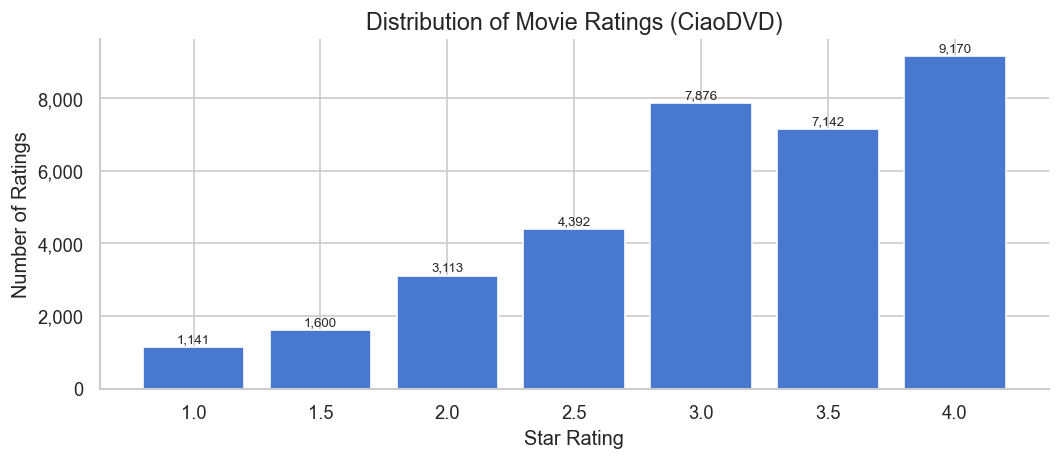

Saved rating_distribution.png


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

rating_counts = ratings_clean['rating'].value_counts().sort_index()

bars = ax.bar(
    rating_counts.index,
    rating_counts.values,
    color=sns.color_palette('muted')[0],
    edgecolor='white',
    width=0.4   # narrower so bars don't touch
)

# Annotate bars
for bar, count in zip(bars, rating_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Ratings', fontsize=12)
ax.set_title('Distribution of Movie Ratings (CiaoDVD)', fontsize=14)
ax.set_xticks(sorted(ratings_clean['rating'].unique()))  # use actual values
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'rating_distribution.png'), dpi=250)
plt.show()
print('Saved rating_distribution.png')

**Finding:** The ratings are negatively skewed as higher ratings are also more frequent than lower ratings.

### 5.2 Long-Tail Distribution — Ratings per User

In [22]:
ratings_per_user = ratings_clean.groupby('userId').size().sort_values(ascending=False).reset_index()
ratings_per_user.columns = ['userId', 'num_ratings']

print(ratings_per_user['num_ratings'].describe())

count    1504.000000
mean       22.894947
std        22.873534
min         1.000000
25%         6.000000
50%        15.000000
75%        37.000000
max       237.000000
Name: num_ratings, dtype: float64


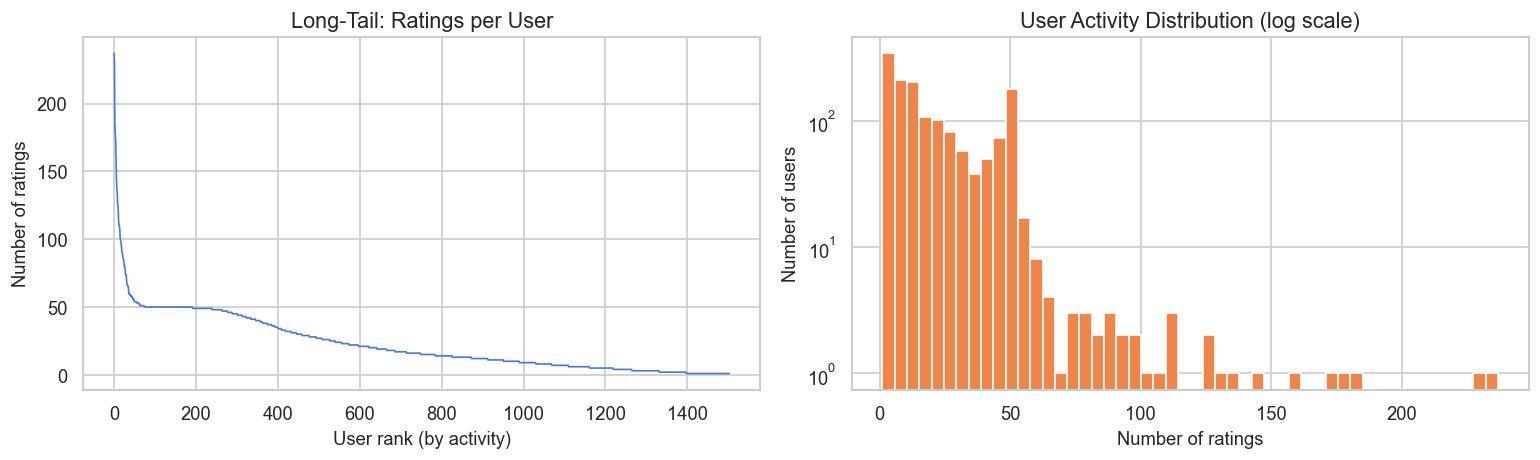

Saved long_tail_users.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: long-tail plot (sorted by count)
axes[0].plot(range(len(ratings_per_user)), ratings_per_user['num_ratings'], linewidth=1)
axes[0].set_xlabel('User rank (by activity)', fontsize=11)
axes[0].set_ylabel('Number of ratings', fontsize=11)
axes[0].set_title('Long-Tail: Ratings per User', fontsize=13)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: histogram (log scale for readability)
axes[1].hist(ratings_per_user['num_ratings'], bins=50, color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_xlabel('Number of ratings', fontsize=11)
axes[1].set_ylabel('Number of users', fontsize=11)
axes[1].set_title('User Activity Distribution (log scale)', fontsize=13)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'long_tail_users.png'), dpi=150)
plt.show()
print('Saved long_tail_users.png')

**Finding:** Positively skewed with the long-tail. Meaning most users rate very few movies.

### 5.3 Long-Tail Distribution — Ratings per Movie

In [24]:
ratings_per_movie = ratings_clean.groupby('movieId').size().sort_values(ascending=False).reset_index()
ratings_per_movie.columns = ['movieId', 'num_ratings']

print(ratings_per_movie['num_ratings'].describe())

count    2044.000000
mean       16.846380
std        90.068272
min         1.000000
25%         1.000000
50%         2.000000
75%         3.250000
max      1022.000000
Name: num_ratings, dtype: float64


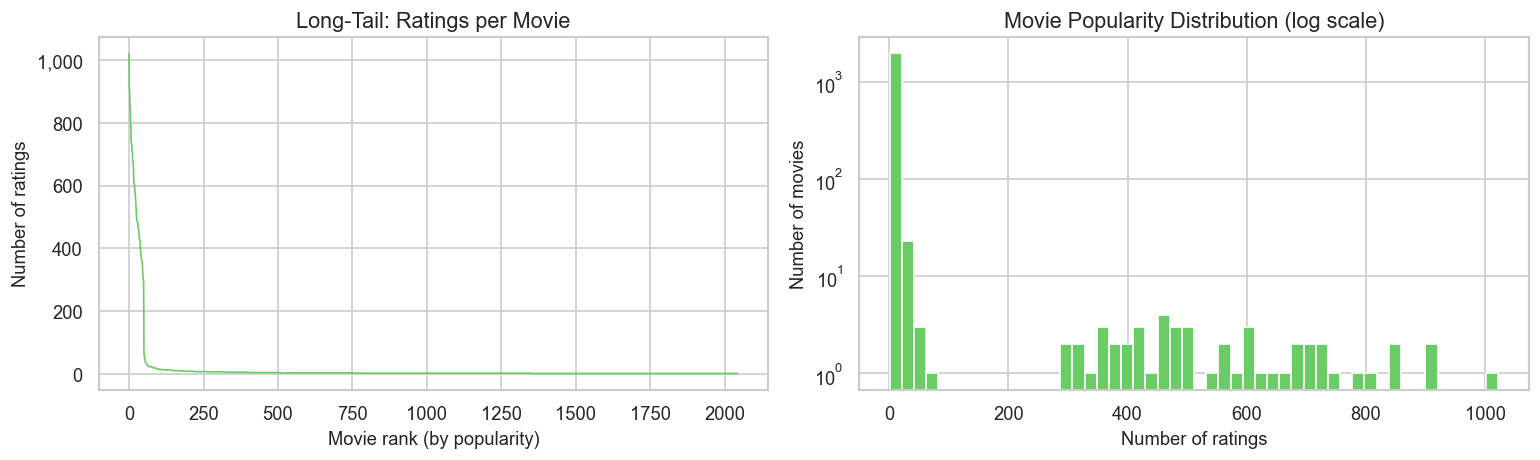

Saved long_tail_movies.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(len(ratings_per_movie)), ratings_per_movie['num_ratings'], linewidth=1, color=sns.color_palette('muted')[2])
axes[0].set_xlabel('Movie rank (by popularity)', fontsize=11)
axes[0].set_ylabel('Number of ratings', fontsize=11)
axes[0].set_title('Long-Tail: Ratings per Movie', fontsize=13)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(ratings_per_movie['num_ratings'], bins=50, color=sns.color_palette('muted')[2], edgecolor='white')
axes[1].set_xlabel('Number of ratings', fontsize=11)
axes[1].set_ylabel('Number of movies', fontsize=11)
axes[1].set_title('Movie Popularity Distribution (log scale)', fontsize=13)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'long_tail_movies.png'), dpi=150)
plt.show()
print('Saved long_tail_movies.png')

**Finding:** *(Most movies receive very few ratings. How does this affect recommendations?)*

---
## 6. Summary of Key Findings

| Metric | Value |
|--------|-------|
| Total users | 1,508 |
| Total movies | 2,071 |
| Total ratings | 35,497 |
| Matrix sparsity | 98.8634% |
| Median ratings per user | 15 |
| Median ratings per movie | 2 |

**Key observations:**
- The rating matrix is extremely sparse at 98.86%, meaning the vast majority of user-movie pairs have no rating. This is a core challenge for any recommendation algorithm.
- User activity follows a strong long-tail pattern. The median user has rated only 15 movies, but the top user has rated 237. The top 25% of users account for the bulk of all ratings.
- Movies are even more skewed. The median movie has only 2 ratings, and 25% of movies have just 1. Only a small number of popular titles (max: 1,022 ratings) drive most of the data.
- Ratings include half-star values (0.5 increments from 1–5), not just whole integers as the dataset documentation suggests.